In [15]:
import pandas as pd 
file = r'E:\seoul\480_based\statistics\SDM_SDEM_all_params.xlsx'
pd.read_excel(file)

,Year,Grid,Target,Model,Formula,CONSTANT,BCR,BHV,SVF,NDVI,...,W_NDVI,W_EV,W_WR,W_nor_2023,lambda,W_ext_2023,W_hr_2023,W_nor_2016,W_ext_2016,W_hr_2016
0,2023,480m,nor_2023,SDM,nor_2023 = 30.1599 + 0.5751*Wnor_2023 + 0.0448...,30.159933,0.044773,0.015375,10.798249,-26.223267,...,12.814888,-0.000515,0.074652,0.575115,NaN,NaN,NaN,NaN,NaN,NaN
1,2023,480m,nor_2023,SDEM,nor_2023 = 37.4249 + 0.0267*BCR + 0.0033*BHV +...,37.424907,0.026744,0.003328,7.780677,-27.537984,...,-2.964007,-0.002068,-0.029169,NaN,0.824989,NaN,NaN,NaN,NaN,NaN
2,2023,480m,ext_2023,SDM,ext_2023 = 29.3256 + 0.7471*Wext_2023 + 0.0476...,29.325550,0.047562,0.014412,12.402488,-27.337770,...,18.773119,0.001307,0.110031,NaN,NaN,0.747101,NaN,NaN,NaN,NaN
3,2023,480m,ext_2023,SDEM,ext_2023 = 40.0883 + 0.0256*BCR + 0.0006*BHV +...,40.088276,0.025627,0.000633,8.361636,-29.420366,...,-4.276874,0.002627,-0.030358,NaN,0.906532,NaN,NaN,NaN,NaN,NaN
4,2023,480m,hr_2023,SDM,hr_2023 = -1.1990 + 0.9467*Whr_2023 + 0.0010*B...,-1.198987,0.000973,0.004715,-0.729354,1.419924,...,-1.459307,0.000313,-0.001347,NaN,NaN,NaN,0.946731,NaN,NaN,NaN
5,2023,480m,hr_2023,SDEM,hr_2023 = -2.5438 + 0.0004*BCR + 0.0032*BHV + ...,-2.543829,0.000404,0.003207,-0.642424,1.692753,...,0.780231,-0.003769,-0.000409,NaN,0.953690,NaN,NaN,NaN,NaN,NaN
6,2016,480m,nor_2016,SDM,nor_2016 = 23.2855 + 0.5826*Wnor_2016 + 0.0338...,23.285463,0.033750,0.012843,10.900458,-20.087470,...,2.695392,0.004963,0.033156,NaN,NaN,NaN,NaN,0.582557,NaN,NaN
7,2016,480m,nor_2016,SDEM,nor_2016 = 27.5798 + 0.0203*BCR + 0.0014*BHV +...,27.579828,0.020284,0.001419,8.427382,-21.445966,...,-10.587574,0.003948,-0.039357,NaN,0.818419,NaN,NaN,NaN,NaN,NaN
8,2016,480m,ext_2016,SDM,ext_2016 = 33.0126 + 0.5725*Wext_2016 + 0.0520...,33.012580,0.052031,0.011752,12.591951,-37.396405,...,14.029398,0.004659,0.075811,NaN,NaN,NaN,NaN,NaN,0.572461,NaN
9,2016,480m,ext_2016,SDEM,ext_2016 = 39.3798 + 0.0326*BCR + -0.0036*BHV ...,39.379793,0.032600,-0.003562,8.903899,-38.829388,...,-9.761718,0.005035,-0.044355,NaN,0.839985,NaN,NaN,NaN,NaN,NaN


In [ ]:
import geopandas as gpd
import numpy as np
file  = r'E:\seoul\480_based\city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)
gdf_clean['hr_2016'].head(20
)

0     -5.594814
1     -6.555527
2     -8.384675
3     -8.254778
4     -7.365076
5    -10.595286
6     -8.754495
7     -9.188962
8     -7.116199
9     -5.974131
10    -7.212986
11    -9.219296
12    -8.863935
13   -10.256617
14   -11.078860
15    -8.307545
16    -6.195232
17    -8.259084
18    -8.042412
19   -10.235701
Name: hr_2016, dtype: float64

# 480 SDM

In [2]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"E:\seoul\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
results_list = []
def show_formula(model, model_type='SDM'):
    # 处理 y 名称
    y_name = model.name_y if isinstance(model.name_y, str) else model.name_y[0]

    coefs = model.betas.flatten()
    vars_ = model.name_x

    terms = []
    for coef, var in zip(coefs, vars_):
        if var.lower() in ['const', 'constant']:  # 常数项
            terms.append(f"{coef:.4f}")
        else:
            terms.append(f"{coef:.4f}*{var}")

    formula = f"{y_name} = "

    # SDM rho 处理
    if model_type == 'SDM' and hasattr(model, 'rho'):
        rho_term = f"{model.rho:.4f}*W{y_name}"
        formula += " + ".join(terms[:1] + [rho_term] + terms[1:])  # 常数项 0 + Wy + X + WX
        return formula

    # SDEM lambda 处理
    if model_type == 'SDEM' and hasattr(model, 'lambda_'):
        terms.append(f"{model.lambda_:.4f}*error")

    formula += " + ".join(terms)
    return formula


param_list = []

for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith('.shp') and filename.startswith(f'city{year}_lst_ratio_grid_480m'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 只保留完整数据
                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print(f"CRS: {data_gdf.crs}, File: {filename}, Target: {target}")

                # -----------------------------
                # 空间权重矩阵
                # -----------------------------
                threshold = 1000
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # -----------------------------
                # y 与 X
                # -----------------------------
                yi = data[target].values.reshape(-1, 1)
                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]
                # print(len(name_x), X_all.shape[1])
                
                n, k = X_main.shape  # 原始自变量数量

                # -----------------------------
                # 模型估计
                # -----------------------------
                models = {}

                # SDM
                models['SDM'] = ML_Lag(
                    yi, X_all, w=w,
                    name_y=target, name_x=name_x,
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True, spat_impacts=['full']
                )

                # SDEM
                models['SDEM'] = ML_Error(
                    yi, X_all, w=w,
                    name_y=target, name_x=name_x,
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True
                )

                # -----------------------------
                # 提取 AIC/BIC/logLik
                # -----------------------------
                for model_name, model in models.items():
                    loglik = model.logll
                    aic = model.aic

                    # 参数数量估算
                    if model_name in ['SDM', 'SDEM']:
                        n_params = 2 * k + 3  # k原始 + k滞后 + ρ/λ + 常数 + σ²
                    else:
                        n_params = k + 2

                    bic = -2 * loglik + n_params * np.log(n)

                    results_list.append({
                        "Year": year,
                        "Grid": filename.split("_")[4],
                        "Target": target,
                        "Model": model_name,
                        "AIC": round(aic, 2),
                        "BIC": round(bic, 2),
                        "LogLik": round(loglik, 2),
                        "N": n
                    })

                    formula_sdm = show_formula(models['SDM'], model_type='SDM')
                    print(formula_sdm)
                    formula_sdem = show_formula(models['SDEM'], model_type='SDEM')

                    # 系数转成 dict，列名是变量名
                    coef_sdm = dict(zip(models['SDM'].name_x, models['SDM'].betas.flatten()))
                    coef_sdem = dict(zip(models['SDEM'].name_x, models['SDEM'].betas.flatten()))

                    #  lambda_ 加进去, rho 不用加是因为已经有Wy了
                    if hasattr(models['SDEM'], 'lambda_'):
                        coef_sdem['lambda'] = models['SDEM'].lambda_


                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "Formula": formula_sdm,
                    **coef_sdm
                })

                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDEM",
                    "Formula": formula_sdem,
                    **coef_sdem
                })


# -----------------------------
# 汇总输出
# -----------------------------
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])
output_path = os.path.join(output_folder, "SDM_SDEM_clean_AIC_BIC_480m_NOW.xlsx")
results_df.to_excel(output_path, index=False)
all_params_df = pd.DataFrame(param_list)
param_output = os.path.join(output_folder, "SDM_SDEM_all_params_480m_NOW.xlsx")
all_params_df.to_excel(param_output, index=False)


print(f"✅ 所有模型（SDM/SDEM）AIC/BIC 结果已保存到：\n{output_path}")

CRS: EPSG:5181, File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: nor_2023
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


nor_2023 = 30.1599 + 0.5751*Wnor_2023 + 0.0448*BCR + 0.0154*BHV + 10.7982*SVF + -26.2233*NDVI + -0.0125*EV + -0.1693*WR + -0.1100*Dist_W + -0.0776*Dist_P + -0.0106*Dist_M + -0.1046*W_BCR + -0.1183*W_BHV + -20.6142*W_SVF + 12.8149*W_NDVI + -0.0005*W_EV + 0.0747*W_WR + 0.5751*W_nor_2023
nor_2023 = 30.1599 + 0.5751*Wnor_2023 + 0.0448*BCR + 0.0154*BHV + 10.7982*SVF + -26.2233*NDVI + -0.0125*EV + -0.1693*WR + -0.1100*Dist_W + -0.0776*Dist_P + -0.0106*Dist_M + -0.1046*W_BCR + -0.1183*W_BHV + -20.6142*W_SVF + 12.8149*W_NDVI + -0.0005*W_EV + 0.0747*W_WR + 0.5751*W_nor_2023
CRS: EPSG:5181, File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: ext_2023
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


ext_2023 = 29.3256 + 0.7471*Wext_2023 + 0.0476*BCR + 0.0144*BHV + 12.4025*SVF + -27.3378*NDVI + -0.0127*EV + -0.1678*WR + -0.0464*Dist_W + -0.0227*Dist_P + -0.0636*Dist_M + -0.1205*W_BCR + -0.1437*W_BHV + -28.2722*W_SVF + 18.7731*W_NDVI + 0.0013*W_EV + 0.1100*W_WR + 0.7471*W_ext_2023
ext_2023 = 29.3256 + 0.7471*Wext_2023 + 0.0476*BCR + 0.0144*BHV + 12.4025*SVF + -27.3378*NDVI + -0.0127*EV + -0.1678*WR + -0.0464*Dist_W + -0.0227*Dist_P + -0.0636*Dist_M + -0.1205*W_BCR + -0.1437*W_BHV + -28.2722*W_SVF + 18.7731*W_NDVI + 0.0013*W_EV + 0.1100*W_WR + 0.7471*W_ext_2023
CRS: EPSG:5181, File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: hr_2023
('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')


...

nor_2016 = 23.2855 + 0.5826*Wnor_2016 + 0.0338*BCR + 0.0128*BHV + 10.9005*SVF + -20.0875*NDVI + -0.0123*EV + -0.1102*WR + -0.0086*Dist_W + -0.0056*Dist_P + -0.0228*Dist_M + -0.1100*W_BCR + -0.1021*W_BHV + -16.4776*W_SVF + 2.6954*W_NDVI + 0.0050*W_EV + 0.0332*W_WR + 0.5826*W_nor_2016
nor_2016 = 23.2855 + 0.5826*Wnor_2016 + 0.0338*BCR + 0.0128*BHV + 10.9005*SVF + -20.0875*NDVI + -0.0123*EV + -0.1102*WR + -0.0086*Dist_W + -0.0056*Dist_P + -0.0228*Dist_M + -0.1100*W_BCR + -0.1021*W_BHV + -16.4776*W_SVF + 2.6954*W_NDVI + 0.0050*W_EV + 0.0332*W_WR + 0.5826*W_nor_2016
CRS: EPSG:5181, File: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: ext_2016
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


ext_2016 = 33.0126 + 0.5725*Wext_2016 + 0.0520*BCR + 0.0118*BHV + 12.5920*SVF + -37.3964*NDVI + -0.0154*EV + -0.1850*WR + -0.0849*Dist_W + -0.0030*Dist_P + -0.0828*Dist_M + -0.1396*W_BCR + -0.1200*W_BHV + -21.7296*W_SVF + 14.0294*W_NDVI + 0.0047*W_EV + 0.0758*W_WR + 0.5725*W_ext_2016
ext_2016 = 33.0126 + 0.5725*Wext_2016 + 0.0520*BCR + 0.0118*BHV + 12.5920*SVF + -37.3964*NDVI + -0.0154*EV + -0.1850*WR + -0.0849*Dist_W + -0.0030*Dist_P + -0.0828*Dist_M + -0.1396*W_BCR + -0.1200*W_BHV + -21.7296*W_SVF + 14.0294*W_NDVI + 0.0047*W_EV + 0.0758*W_WR + 0.5725*W_ext_2016
CRS: EPSG:5181, File: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: hr_2016
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


hr_2016 = -9.1532 + 0.8417*Whr_2016 + -0.0197*BCR + 0.0003*BHV + -1.9617*SVF + 17.0564*NDVI + 0.0032*EV + 0.0734*WR + 0.0407*Dist_W + -0.0050*Dist_P + 0.0409*Dist_M + 0.0547*W_BCR + 0.0456*W_BHV + 8.5564*W_SVF + -13.9486*W_NDVI + 0.0001*W_EV + -0.0581*W_WR + 0.8417*W_hr_2016
hr_2016 = -9.1532 + 0.8417*Whr_2016 + -0.0197*BCR + 0.0003*BHV + -1.9617*SVF + 17.0564*NDVI + 0.0032*EV + 0.0734*WR + 0.0407*Dist_W + -0.0050*Dist_P + 0.0409*Dist_M + 0.0547*W_BCR + 0.0456*W_BHV + 8.5564*W_SVF + -13.9486*W_NDVI + 0.0001*W_EV + -0.0581*W_WR + 0.8417*W_hr_2016
✅ 所有模型（SDM/SDEM）AIC/BIC 结果已保存到：
E:\seoul\480_based\statistics\SDM_SDEM_clean_AIC_BIC_480m_NOW.xlsx


In [ ]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"E:\seoul\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
results_list = []
def show_formula(model, model_type='SDM'):
    # 处理 y 名称
    y_name = model.name_y if isinstance(model.name_y, str) else model.name_y[0]

    coefs = model.betas.flatten()
    vars_ = model.name_x

    terms = []
    for coef, var in zip(coefs, vars_):
        if var.lower() in ['const', 'constant']:  # 常数项
            terms.append(f"{coef:.4f}")
        else:
            terms.append(f"{coef:.4f}*{var}")

    formula = f"{y_name} = "

    # SDM rho 处理
    if model_type == 'SDM' and hasattr(model, 'rho'):
        rho_term = f"{model.rho:.4f}*W{y_name}"
        formula += " + ".join(terms[:1] + [rho_term] + terms[1:])  # 常数项 0 + Wy + X + WX
        return formula

    # SDEM lambda 处理
    if model_type == 'SDEM' and hasattr(model, 'lambda_'):
        terms.append(f"{model.lambda_:.4f}*error")

    formula += " + ".join(terms)
    return formula


param_list = []

for year in [2023, 2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith('.shp') and filename.startswith(f'city{year}_lst_ratio_grid_120m'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 只保留完整数据
                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print(f"CRS: {data_gdf.crs}, File: {filename}, Target: {target}")

                # -----------------------------
                # 空间权重矩阵
                # -----------------------------
                threshold = 1000
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # -----------------------------
                # y 与 X
                # -----------------------------
                yi = data[target].values.reshape(-1, 1)
                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]
                # print(len(name_x), X_all.shape[1])
                
                n, k = X_main.shape  # 原始自变量数量

                # -----------------------------
                # 模型估计
                # -----------------------------
                models = {}

                # SDM
                models['SDM'] = ML_Lag(
                    yi, X_all, w=w,
                    name_y=target, name_x=name_x,
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True, spat_impacts=['full']
                )

                # SDEM
                models['SDEM'] = ML_Error(
                    yi, X_all, w=w,
                    name_y=target, name_x=name_x,
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True
                )

                # -----------------------------
                # 提取 AIC/BIC/logLik
                # -----------------------------
                for model_name, model in models.items():
                    loglik = model.logll
                    aic = model.aic

                    # 参数数量估算
                    if model_name in ['SDM', 'SDEM']:
                        n_params = 2 * k + 3  # k原始 + k滞后 + ρ/λ + 常数 + σ²
                    else:
                        n_params = k + 2

                    bic = -2 * loglik + n_params * np.log(n)

                    results_list.append({
                        "Year": year,
                        "Grid": filename.split("_")[4],
                        "Target": target,
                        "Model": model_name,
                        "AIC": round(aic, 2),
                        "BIC": round(bic, 2),
                        "LogLik": round(loglik, 2),
                        "N": n
                    })

                    formula_sdm = show_formula(models['SDM'], model_type='SDM')
                    print(formula_sdm)
                    formula_sdem = show_formula(models['SDEM'], model_type='SDEM')

                    # 系数转成 dict，列名是变量名
                    coef_sdm = dict(zip(models['SDM'].name_x, models['SDM'].betas.flatten()))
                    coef_sdem = dict(zip(models['SDEM'].name_x, models['SDEM'].betas.flatten()))

                    #  lambda_ 加进去, rho 不用加是因为已经有Wy了
                    if hasattr(models['SDEM'], 'lambda_'):
                        coef_sdem['lambda'] = models['SDEM'].lambda_


                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "Formula": formula_sdm,
                    **coef_sdm
                })

                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDEM",
                    "Formula": formula_sdem,
                    **coef_sdem
                })


# -----------------------------
# 汇总输出
# -----------------------------
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(["Year", "Target", "Model"])
output_path = os.path.join(output_folder, "SDM_SDEM_clean_AIC_BIC_120m.xlsx")
results_df.to_excel(output_path, index=False)
all_params_df = pd.DataFrame(param_list)
param_output = os.path.join(output_folder, "SDEM_all_params_120m.xlsx")
all_params_df.to_excel(param_output, index=False)


print(f"✅ 所有模型（SDM/SDEM）AIC/BIC 结果已保存到：\n{output_path}")

c:\Users\JUJUBE\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


CRS: EPSG:5181, File: city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: nor_2023


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


nor_2023 = -0.7121 + 0.9928*Wnor_2023 + 0.0239*BCR + -0.0039*BHV + 4.8800*SVF + -22.4416*NDVI + -0.0176*EV + -0.1437*WR + -0.0256*Dist_W + -0.0401*Dist_P + -0.0056*Dist_M + -0.0249*W_BCR + 0.0212*W_BHV + -3.1962*W_SVF + 20.2515*W_NDVI + 0.0190*W_EV + 0.1269*W_WR + 0.9928*W_nor_2023
nor_2023 = -0.7121 + 0.9928*Wnor_2023 + 0.0239*BCR + -0.0039*BHV + 4.8800*SVF + -22.4416*NDVI + -0.0176*EV + -0.1437*WR + -0.0256*Dist_W + -0.0401*Dist_P + -0.0056*Dist_M + -0.0249*W_BCR + 0.0212*W_BHV + -3.1962*W_SVF + 20.2515*W_NDVI + 0.0190*W_EV + 0.1269*W_WR + 0.9928*W_nor_2023
CRS: EPSG:5181, File: city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: ext_2023


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(
c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\optimize\_minimize.py:892: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  warn("Method 'bounded' does not support relative tolerance in x; "


ext_2023 = -0.4189 + 0.9952*Wext_2023 + 0.0240*BCR + -0.0050*BHV + 5.1967*SVF + -23.7155*NDVI + -0.0169*EV + -0.1462*WR + -0.0205*Dist_W + -0.0407*Dist_P + -0.0109*Dist_M + -0.0246*W_BCR + 0.0123*W_BHV + -3.9160*W_SVF + 21.5837*W_NDVI + 0.0182*W_EV + 0.1311*W_WR + 0.9952*W_ext_2023
ext_2023 = -0.4189 + 0.9952*Wext_2023 + 0.0240*BCR + -0.0050*BHV + 5.1967*SVF + -23.7155*NDVI + -0.0169*EV + -0.1462*WR + -0.0205*Dist_W + -0.0407*Dist_P + -0.0109*Dist_M + -0.0246*W_BCR + 0.0123*W_BHV + -3.9160*W_SVF + 21.5837*W_NDVI + 0.0182*W_EV + 0.1311*W_WR + 0.9952*W_ext_2023
CRS: EPSG:5181, File: city2023_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: hr_2023


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
  W.__init__(


MemoryError: Unable to allocate 4.40 GiB for an array with shape (24306, 24306) and data type float64

In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
# 设置文件夹、变量
grid_folder = r'E:\seoul\480_based'
output_fig_dir = r'E:\seoul\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

years = [2016]

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\2016_R2_Comparison_Retrained_0_9394_120m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDEM_all_params_240m.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()
    print(target_folder)

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- EXT + NOR 合并 ----------------
        for feature in explanatory_vars:
            output_path = os.path.join(output_dir, f'{feature}_hr_{year}_comparison_120m.png')
            
            # # 👉 如果文件已存在且大小大于 10KB，就跳过
            # if os.path.exists(output_path) and os.path.getsize(output_path) > 10 * 1024:
            #     print(f"⏩ 跳过 {feature}_hr_{year}_comparison_120m.png（已存在）")
            #     continue

            plt.figure(figsize=(8,5))
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]
                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = random_seeds[0])
                model = GradientBoostingRegressor(**params_gbdt).fit(X_train, y_train)

                # ----------- PDP 计算部分 -----------
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns)
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)


                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }
                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])
                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                y_sdem_pred = np.array(y_sdem_pred)


                color_gbdt = '#333333'  # 黑色
                color_sdem = '#555555'  # 黑色虚线

                # 命名规范映射
                target_name_map = {
                    'nor_2023': 'Nor_LST',
                    'ext_2023': 'Ext_LST',
                    'hr_2023': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名
                # 绘图
                for x in X[feature]:
                    plt.axvline(x=x, color='gray', alpha=0.1, linewidth=0.1)
                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')


            # 设置全局字体为 Times New Roman
            plt.rcParams["font.family"] = "Times New Roman"
            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)

            plt.legend(loc='upper right', frameon=False, fontsize=12)

            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(output_path, dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison_120m.png")


['nor_2016' 'ext_2016' 'hr_2016']


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  W.__init__(


✅ Saved BCR_hr_2016_comparison_120m.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  W.__init__(


✅ Saved BHV_hr_2016_comparison_120m.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  W.__init__(


✅ Saved SVF_hr_2016_comparison_120m.png


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 10 disconnected components.
  W.__init__(


✅ Saved NDVI_hr_2016_comparison_120m.png


# 1 纯净的SDM MODEL

In [22]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Lag
from libpysal.weights import lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"E:\seoul\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备函数
# -----------------------------
def show_formula(model):
    """输出 SDM 模型公式"""
    y_name = model.name_y if isinstance(model.name_y, str) else model.name_y[0]
    coefs = model.betas.flatten()
    vars_ = model.name_x

    terms = []
    for coef, var in zip(coefs, vars_):
        if var.lower() in ['const', 'constant']:
            terms.append(f"{coef:.4f}")
        else:
            terms.append(f"{coef:.4f}*{var}")

    rho_term = f"{model.rho:.4f}*W{y_name}"
    formula = f"{y_name} = " + " + ".join(terms) 
    return formula



# -----------------------------
# 主循环
# -----------------------------
param_list = []

for year in [2016, 2023]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith('.shp') and filename.startswith(f'city{year}_lst_ratio_grid_480m'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 只保留完整数据
                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print(f"CRS: {data_gdf.crs}, File: {filename}, Target: {target}")

                # -----------------------------
                # 空间权重矩阵
                # -----------------------------
                threshold = 1000
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r' # 行标准化（transform＝'r'）有意义
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # -----------------------------
                # y 与 X
                # -----------------------------
                yi = data[target].values.reshape(-1, 1)
                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                name_x = ['const'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]

                # -----------------------------
                # SDM 模型估计
                # -----------------------------
                model = ML_Lag(
                    yi, X_all, w=w,
                    name_y=target, name_x=name_x,
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True, spat_impacts=['full']
                )

                # 打印公式
                formula_sdm = show_formula(model)
                print(formula_sdm)

                # 提取系数
                coef_sdm = dict(zip(model.name_x, model.betas.flatten()))

                # 保存结果
                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "Formula": formula_sdm,
                    **coef_sdm
                })
                

# -----------------------------
# 汇总输出
# -----------------------------
all_params_df = pd.DataFrame(param_list)
param_output = os.path.join(output_folder, "SDM_all_params.xlsx")
all_params_df.to_excel(param_output, index=False)

print(f"✅ SDM 模型参数结果已保存到：\n{param_output}")


CRS: EPSG:5181, File: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: nor_2016


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
nor_2016 = 23.2855 + 0.0338*BCR + 0.0128*BHV + 10.9005*SVF + -20.0875*NDVI + -0.0123*EV + -0.1102*WR + -0.0086*Dist_W + -0.0056*Dist_P + -0.0228*Dist_M + -0.1100*W_BCR + -0.1021*W_BHV + -16.4776*W_SVF + 2.6954*W_NDVI + 0.0050*W_EV + 0.0332*W_WR + 0.5826*W_nor_2016
CRS: EPSG:5181, File: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: ext_2016


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')
ext_2016 = 33.0126 + 0.0520*BCR + 0.0118*BHV + 12.5920*SVF + -37.3964*NDVI + -0.0154*EV + -0.1850*WR + -0.0849*Dist_W + -0.0030*Dist_P + -0.0828*Dist_M + -0.1396*W_BCR + -0.1200*W_BHV + -21.7296*W_SVF + 14.0294*W_NDVI + 0.0047*W_EV + 0.0758*W_WR + 0.5725*W_ext_2016
CRS: EPSG:5181, File: city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: hr_2016


...

('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
nor_2023 = 30.1599 + 0.0448*BCR + 0.0154*BHV + 10.7982*SVF + -26.2233*NDVI + -0.0125*EV + -0.1693*WR + -0.1100*Dist_W + -0.0776*Dist_P + -0.0106*Dist_M + -0.1046*W_BCR + -0.1183*W_BHV + -20.6142*W_SVF + 12.8149*W_NDVI + -0.0005*W_EV + 0.0747*W_WR + 0.5751*W_nor_2023
CRS: EPSG:5181, File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: ext_2023


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
ext_2023 = 29.3256 + 0.0476*BCR + 0.0144*BHV + 12.4025*SVF + -27.3378*NDVI + -0.0127*EV + -0.1678*WR + -0.0464*Dist_W + -0.0227*Dist_P + -0.0636*Dist_M + -0.1205*W_BCR + -0.1437*W_BHV + -28.2722*W_SVF + 18.7731*W_NDVI + 0.0013*W_EV + 0.1100*W_WR + 0.7471*W_ext_2023
CRS: EPSG:5181, File: city2023_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp, Target: hr_2023


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 1392, 1571.
  W.__init__(


('WARNING: ', 1392, ' is an island (no neighbors)')
('WARNING: ', 1571, ' is an island (no neighbors)')
hr_2023 = -1.1990 + 0.0010*BCR + 0.0047*BHV + -0.7294*SVF + 1.4199*NDVI + -0.0001*EV + 0.0003*WR + -0.0084*Dist_W + -0.0002*Dist_P + 0.0124*Dist_M + 0.0002*W_BCR + 0.0001*W_BHV + 1.7678*W_SVF + -1.4593*W_NDVI + 0.0003*W_EV + -0.0013*W_WR + 0.9467*W_hr_2023
✅ SDM 模型参数结果已保存到：
E:\seoul\480_based\statistics\SDM_all_params.xlsx


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


--- 初始权重 w ---

--- 尺寸信息 ---
区域数量 (n): 1861
总连接数 (nnz): 19212
平均邻居数: 10.32
('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')

--- 行标准化后 (w.transform = 'r') ---
行标准化后区域数量 (n): 1861
总连接数 (nnz): 19212
平均邻居数: 10.32


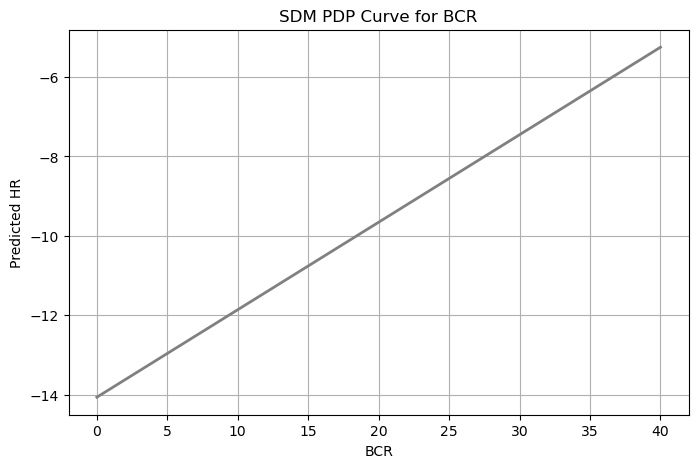

In [ ]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from libpysal.weights import DistanceBand
from numpy.linalg import solve

file  = r'E:\seoul\480_based\city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

explanatory_vars = ['BCR','BHV','SVF','NDVI','EV','WR','Dist_W','Dist_P','Dist_M']
explanatory_vars_clean = ['BCR','BHV','SVF','NDVI','EV','WR']
n = len(gdf_clean)

const = -9.1532
rho = 0.8417
beta = np.array([-0.0197, 0.0003, -1.9617, 17.0564, 0.0032, 0.0734, 0.0407, -0.0050, 0.0409])
theta = np.array([0.0547, 0.0456, 8.5564, -13.9486, 0.0001, -0.0581])

# Spatial weights
w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
w.transform = 'r'
W = np.array(w.full()[0])
I = np.eye(n)
A_inv = np.linalg.inv(I - rho * W)
X_base = gdf_clean[explanatory_vars].mean().values
X_base = np.tile(X_base, (n,1))
BCR_grid = np.linspace(0, 40, 100)
y_pred = []

for bcr_val in BCR_grid:
    X_temp = X_base.copy()
    X_temp[:,0] = bcr_val

    X_beta_vec = X_temp @ beta
    WX_temp = W @ X_temp[:, :len(explanatory_vars_clean)]
    WX_theta_vec = WX_temp @ theta
    base_effect = const + X_beta_vec + WX_theta_vec

    y_pred_grid = A_inv @ base_effect
    y_pred.append(y_pred_grid.mean())

plt.figure(figsize=(8,5))
plt.plot(BCR_grid, y_pred, color='gray', linewidth=2)
plt.xlabel('BCR')
plt.ylabel('Predicted HR')
plt.title('SDM PDP Curve for BCR')
plt.grid(True)
plt.show()


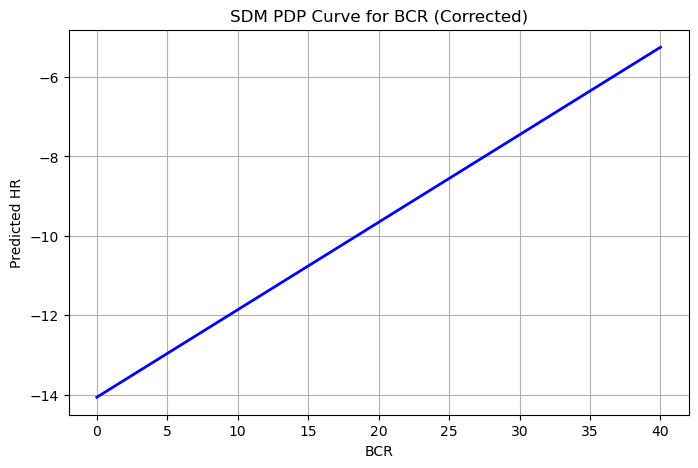

In [20]:
# -----------------------
# PDP 计算 (SDM 总效应 - 同时改变 X 和 WX)
# -----------------------

# W 的构建和系数提取（I, rho, W, constant, beta, theta, n）保持不变

# 1. 准备 X_base
X_base_mean = gdf_clean[explanatory_vars].mean().values  # (k,)
X_base_matrix = np.tile(X_base_mean, (n, 1))  # n x k
feature_idx = explanatory_vars.index('BCR') # 假设 BCR 是您要测量的特征

# 找出 explanatory_vars 中哪些索引对应于 explanatory_vars_clean
clean_vars_set = set(explanatory_vars_clean)
clean_indices = [i for i, var in enumerate(explanatory_vars) if var in clean_vars_set]


y_pred_fixed = [] 
# 2. 循环计算
for bcr_val in BCR_grid:
    X_temp_matrix = X_base_matrix.copy()
    X_temp_matrix[:, feature_idx] = bcr_val  # 仅改变 BCR 列，但 X_temp_matrix 整体是 n x k

    # 1. X*beta 项 (直接效应部分)
    X_beta_vec = X_temp_matrix @ beta  # (n,) 

    # 2. WX*theta 项 (溢出效应部分)
    # 计算 W @ X_temp_matrix (n x k)
    WX_full_matrix = W @ X_temp_matrix
    
    # 从 WX_full_matrix 中提取需要乘以 theta 的列 (n x k_clean)
    WX_theta_input = WX_full_matrix[:, clean_indices]
    WX_theta_vec = WX_theta_input @ theta  # (n,) 

    # 3. 构造非空间扰动项 Z_vec
    # Z_vec = const + X*beta + WX*theta
    Z_vec = const + X_beta_vec + WX_theta_vec 
    
    # 4. 应用空间乘数 (矩阵求逆法)
    propagated_vec = np.linalg.inv(I - rho * W) @ Z_vec 
    
    y_pred_fixed.append(propagated_vec.mean())

# -----------------------
# 绘图
# -----------------------
plt.figure(figsize=(8,5))
# 注意：这里绘制修正后的 y_pred_fixed
plt.plot(BCR_grid, y_pred_fixed, color='blue', linewidth=2) 
plt.xlabel('BCR')
plt.ylabel('Predicted HR')
plt.title('SDM PDP Curve for BCR (Corrected)')
plt.grid(True)
plt.show()

In [ ]:
y_pred_auto = model.predy
y_pred_auto

array([[ -7.69446072],
       [ -7.2436461 ],
       [ -8.2679296 ],
       ...,
       [ -9.67375792],
       [-10.84455672],
       [ -9.45110436]])

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import libpysal
from libpysal.weights import lag_spatial

# 假设 data_gdf 已经是你的 SDM 数据
n = len(data_gdf)
I = np.eye(n)

# -----------------------------
# 构造空间权重矩阵 W
# -----------------------------
threshold = 1000
w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
w.transform = 'r'
W_dense = np.array(w.full()[0])

# -----------------------------
# 提取模型系数
# -----------------------------
coefs = model.betas.flatten()
const = coefs[0]
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

beta = coefs[1:1+len(explanatory_vars)]
theta = coefs[1+len(explanatory_vars):1+len(explanatory_vars)+len(explanatory_vars_clean)]
rho = model.rho

# -----------------------------
# 原始数据矩阵与均值
# -----------------------------
X_main = data_gdf[explanatory_vars].values
X_mean = X_main.mean(axis=0)

# -----------------------------
# PDP 网格
# -----------------------------
feature = 'BCR'
feature_idx = explanatory_vars.index(feature)
X_grid = np.linspace(0, 40, 100)  # BCR 从 0 到 40
y_pred_list = []

for val in X_grid:
    X_temp = np.tile(X_mean, (n,1))
    X_temp[:, feature_idx] = val

    WX_temp = lag_spatial(w, X_temp[:, :len(explanatory_vars_clean)])
    base_vec = const + X_temp @ beta + WX_temp @ theta
    y_temp = np.linalg.inv(I - rho * W_dense) @ base_vec
    y_pred_list.append(y_temp.mean())

# -----------------------------
# 绘图
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(X_grid, y_pred_list, color='gray', linewidth=2)
plt.xlabel('BCR')
plt.ylabel('Predicted HR')
plt.title('SDM PDP Curve for BCR')
plt.grid(True)
plt.show()


c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\JUJUBE\anaconda3\lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 12 disconnected components.
 There are 6 islands with ids: 1308, 1377, 1411, 1471, 1525, 1690.
  W.__init__(


('WARNING: ', 1308, ' is an island (no neighbors)')
('WARNING: ', 1377, ' is an island (no neighbors)')
('WARNING: ', 1411, ' is an island (no neighbors)')
('WARNING: ', 1471, ' is an island (no neighbors)')
('WARNING: ', 1525, ' is an island (no neighbors)')
('WARNING: ', 1690, ' is an island (no neighbors)')


KeyboardInterrupt: 

# 搞个已有值验证一下

c:\Users\JUJUBE\anaconda3\lib\site-packages\scipy\sparse\_data.py:117: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)


平均误差: 0.001795
RMSE: 0.458995
相关系数: 0.966426
      hr_2016  pred_hr_2016     error
0   -5.594814     -7.694597  2.099783
1   -6.555527     -7.243783  0.688256
2   -8.384675     -8.268069 -0.116606
3   -8.254778     -8.422277  0.167499
4   -7.365076     -7.342207 -0.022868
5  -10.595286     -9.135830 -1.459456
6   -8.754495     -8.929055  0.174561
7   -9.188962     -9.432853  0.243891
8   -7.116199     -7.364779  0.248580
9   -5.974131     -7.024193  1.050062
10  -7.212986     -7.258452  0.045466
11  -9.219296     -8.832038 -0.387258
12  -8.863935     -9.408137  0.544201
13 -10.256617    -10.401036  0.144420
14 -11.078860    -10.470125 -0.608736
15  -8.307545     -8.450738  0.143194
16  -6.195232     -7.462649  1.267417
17  -8.259084     -8.315954  0.056871
18  -8.042412     -8.740337  0.697926
19 -10.235701    -10.255158  0.019458


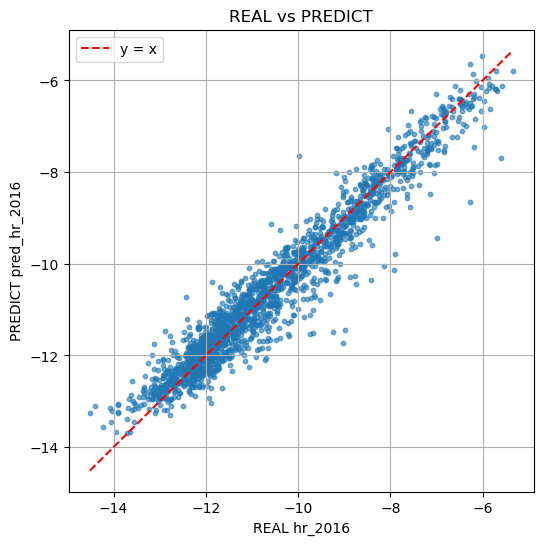

In [ ]:
import geopandas as gpd
import numpy as np
from libpysal.weights import DistanceBand, lag_spatial

# -----------------------------
# 1️⃣ 读取 shapefile
# -----------------------------
file = r'E:\seoul\480_based\city2016_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'
gdf = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

# 你的解释变量（基础项）
vars_base = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']

# -----------------------------
# 2️⃣ 构建空间权重矩阵 W
# -----------------------------
# 这里使用欧式距离权重矩阵，阈值可调整（单位与坐标系统一致）
data_gdf = gdf.loc[data.index]
w = DistanceBand(data_gdf, threshold=1000, binary=False, silence_warnings=True)
w.transform = 'r'
# -----------------------------
# 3️⃣ 计算空间滞后变量（W_X）
# -----------------------------
for var in vars_base + ['hr_2016']:
    gdf[f'W_{var}'] = lag_spatial(w, gdf[var])

# -----------------------------
# 4️⃣ 根据你的 SDM 公式计算预测值
# -----------------------------
gdf['pred_hr_2016'] = (
    -9.1532
    + -0.0197 * gdf['BCR']
    + 0.0003 * gdf['BHV']
    + -1.9617 * gdf['SVF']
    + 17.0564 * gdf['NDVI']
    + 0.0032 * gdf['EV']
    + 0.0734 * gdf['WR']
    + 0.0407 * gdf['Dist_W']
    + -0.0050 * gdf['Dist_P']
    + 0.0409 * gdf['Dist_M']
    + 0.0547 * gdf['W_BCR']
    + 0.0456 * gdf['W_BHV']
    + 8.5564 * gdf['W_SVF']
    + -13.9486 * gdf['W_NDVI']
    + 0.0001 * gdf['W_EV']
    + -0.0581 * gdf['W_WR']
    + 0.8417 * gdf['W_hr_2016']
)

# -----------------------------
# 5️⃣ 比较真实值与预测值
# -----------------------------
gdf['error'] = gdf['hr_2016'] - gdf['pred_hr_2016']
rmse = np.sqrt(np.mean(gdf['error'] ** 2))
corr = np.corrcoef(gdf['hr_2016'], gdf['pred_hr_2016'])[0, 1]

print(f"平均误差: {gdf['error'].mean():.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"相关系数: {corr:.6f}")

# （可选）查看前几行结果
print(gdf[['hr_2016', 'pred_hr_2016', 'error']].head(20))
import matplotlib.pyplot as plt

# 1️⃣ 散点图：真实值 vs 预测值
plt.figure(figsize=(6,6))
plt.scatter(gdf['hr_2016'], gdf['pred_hr_2016'], s=10, alpha=0.6)
plt.plot([gdf['hr_2016'].min(), gdf['hr_2016'].max()],
         [gdf['hr_2016'].min(), gdf['hr_2016'].max()],
         'r--', label='y = x')
plt.xlabel('REAL hr_2016')
plt.ylabel('PREDICT pred_hr_2016')
plt.title('REAL vs PREDICT')
plt.legend()
plt.grid(True)
plt.show()
